In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Set visual style
sns.set_theme(style="whitegrid")
%matplotlib inline

In [4]:
# Load the dataset
df = pd.read_csv('/content/ultimate_student_productivity_dataset_5000.csv')
print(df.info())
display(df.head())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81


,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2500.500000,20.520400,4.539594,2.478734,2.011984,2.998086,1.564514,7.016492,6.979588,74.535600,251.450400,0.498200,0.501400,5.507400,29.431616,45.615324,37.267716,18.803752
std,1443.520003,2.870406,1.821665,1.177990,0.983906,1.467949,1.110807,1.163692,2.486214,42.932293,143.842712,0.500047,0.500048,2.869145,9.962902,14.246591,16.849397,12.130840
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1250.750000,18.000000,3.250000,1.660000,1.320000,1.990000,0.670000,6.237500,5.280000,37.000000,129.000000,0.000000,0.000000,3.000000,22.567500,35.727500,25.290000,9.337500
50%,2500.500000,20.000000,4.530000,2.480000,2.010000,2.980000,1.490000,7.010000,6.950000,75.000000,252.000000,0.000000,1.000000,5.000000,29.430000,45.690000,36.860000,18.010000
75%,3750.250000,23.000000,5.760000,3.290000,2.690000,4.030000,2.340000,7.810000,8.710000,112.000000,376.000000,1.000000,1.000000,8.000000,36.242500,55.352500,49.142500,27.400000
max,5000.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,149.000000,499.000000,1.000000,1.000000,10.000000,63.480000,97.580000,98.020000,64.090000


In [5]:
# Create an in-memory SQL database from the dataframe
engine = create_engine('sqlite://')
df.to_sql('students', engine, index=False)

# Query: High Social Media usage vs Average Productivity
query = """
SELECT Academic_Level, AVG(Productivity_Score) as Avg_Prod
FROM students
WHERE Social_Media_hours > 4
GROUP BY Academic_Level
ORDER BY Avg_Prod DESC
"""
pd.read_sql(query, engine)

,academic_level,Avg_Prod
0,High School,36.465638
1,Undergraduate,35.888058
2,Postgraduate,35.148756


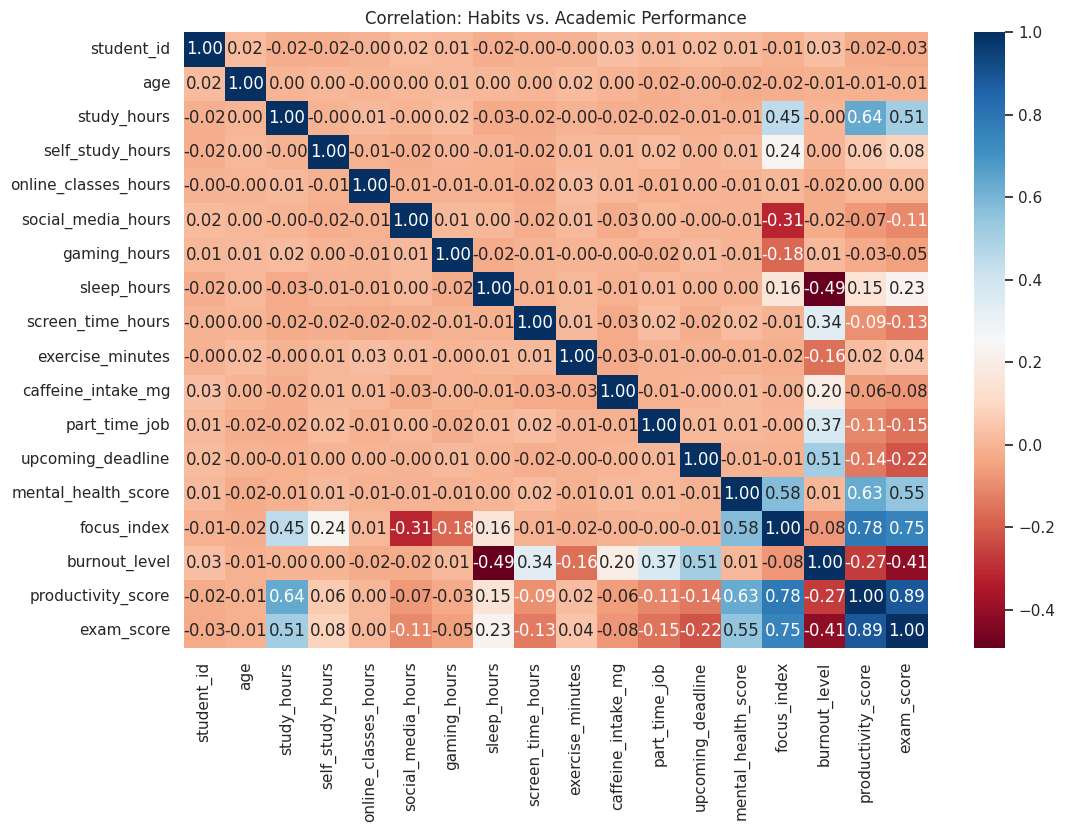

In [6]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title("Correlation: Habits vs. Academic Performance")
plt.show()

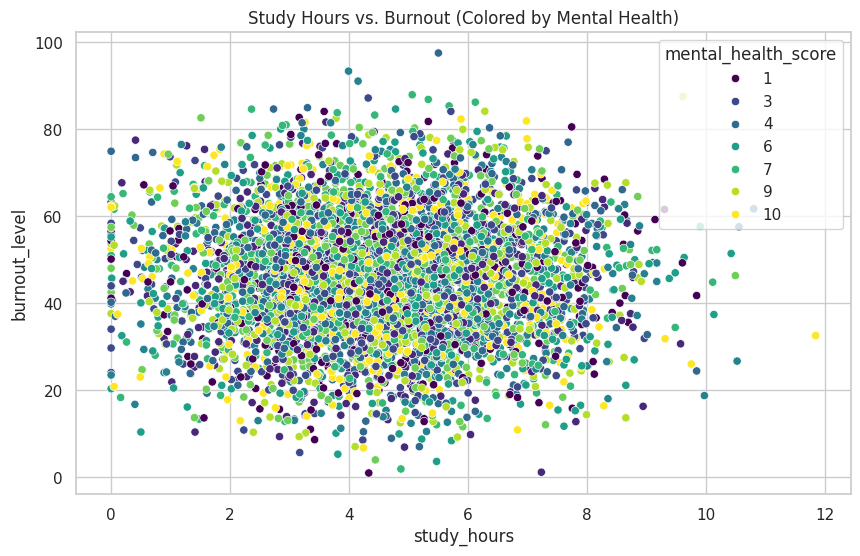

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='study_hours', y='burnout_level', hue='mental_health_score', palette='viridis')
plt.title("Study Hours vs. Burnout (Colored by Mental Health)")
plt.show()

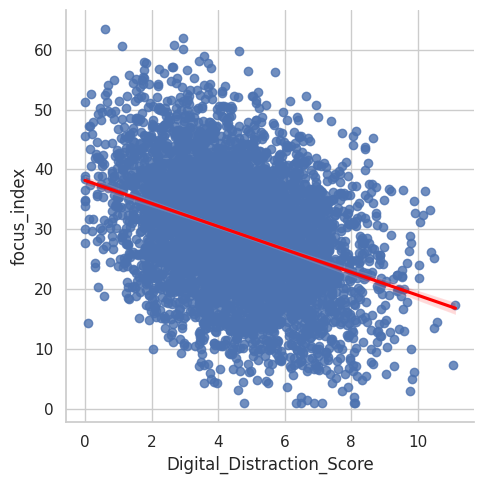

In [8]:
# Creating a composite feature
df['Digital_Distraction_Score'] = df['social_media_hours'] + df['gaming_hours']

# Checking how it impacts the Focus Index
sns.lmplot(x='Digital_Distraction_Score', y='focus_index', data=df, line_kws={'color': 'red'})
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Encode categorical variables (Gender, Academic Level, etc.)
le = LabelEncoder()
df_ml = df.copy()

categorical_cols = df_ml.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# 2. Define Features (X) and Target (y)
# We exclude all targets to predict just the Exam Score for now
targets = ['focus_index', 'burnout_level', 'productivity_score', 'exam_score']
X = df_ml.drop(columns=targets)
y = df_ml['exam_score']

# 3. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Initialize and Train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make Predictions
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f} points")
print(f"R-Squared Score: {r2:.2f}")

Mean Absolute Error: 5.45 points
R-Squared Score: 0.66


/tmp/ipython-input-1555202466.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


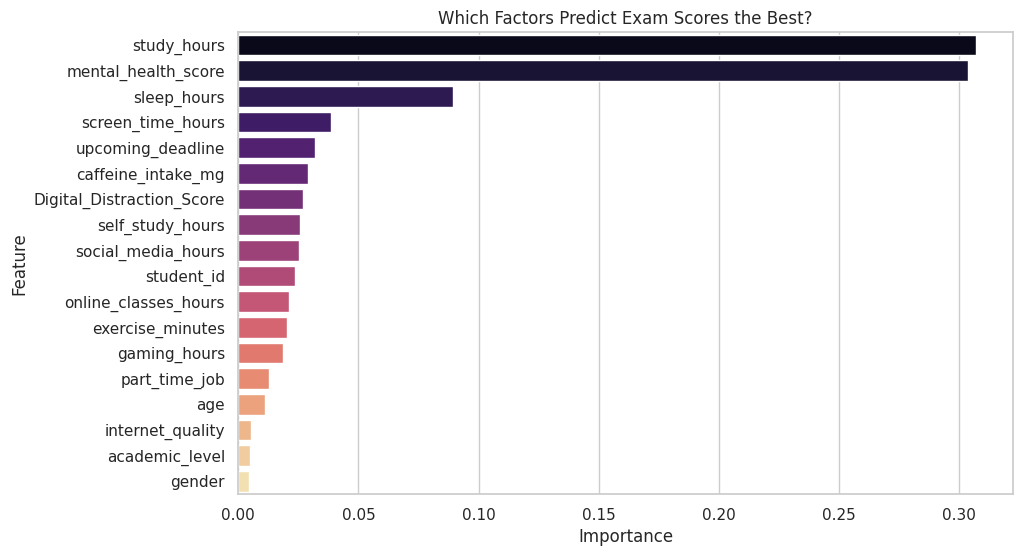

In [11]:
# Get importance levels
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Which Factors Predict Exam Scores the Best?')
plt.show()

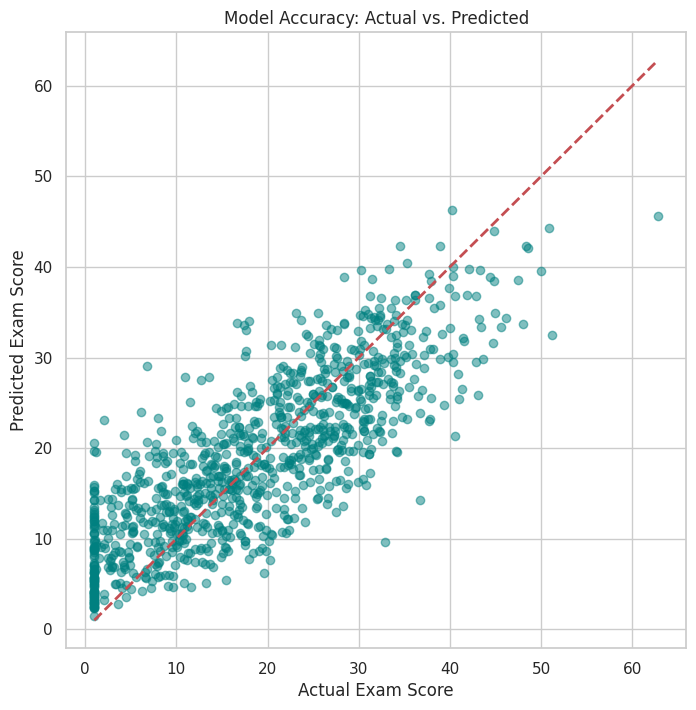

In [12]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Model Accuracy: Actual vs. Predicted')
plt.show()

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Define a threshold for "High Risk"
threshold = df['burnout_level'].quantile(0.75)
df_ml['burnout_risk'] = (df_ml['burnout_level'] > threshold).astype(int)

# Define features (X) and the new classification target (y)
# We drop all potential leakage variables (other target variables)
X_class = df_ml.drop(columns=['focus_index', 'burnout_level', 'productivity_score', 'exam_score', 'burnout_risk'])
y_class = df_ml['burnout_risk']

# Split the data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

In [14]:
# Initialize and Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)

# Predict
y_pred_c = clf.predict(X_test_c)

# Print Performance Report
print(classification_report(y_test_c, y_pred_c, target_names=['Low/Med Risk', 'High Risk']))

              precision    recall  f1-score   support

Low/Med Risk       0.90      0.95      0.93       753
   High Risk       0.82      0.68      0.74       247

    accuracy                           0.88      1000
   macro avg       0.86      0.81      0.83      1000
weighted avg       0.88      0.88      0.88      1000



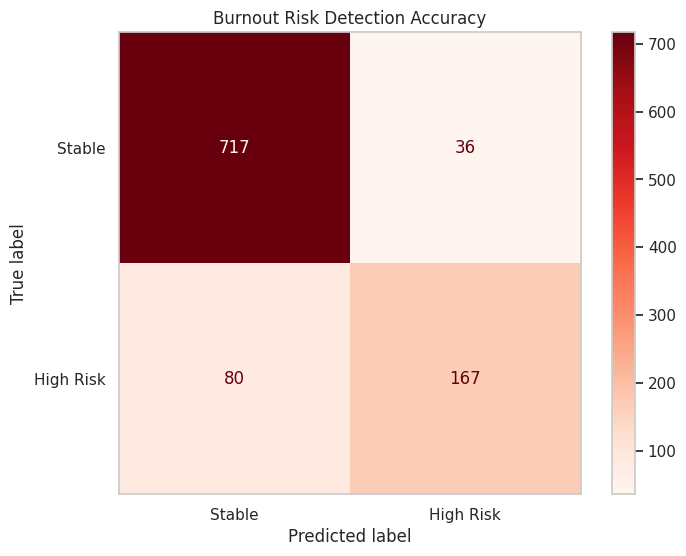

In [15]:
# Plot the Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(clf, X_test_c, y_test_c,
                                      display_labels=['Stable', 'High Risk'],
                                      cmap='Reds', ax=ax)
plt.title('Burnout Risk Detection Accuracy')
plt.grid(False) # Clean up the visual
plt.show()

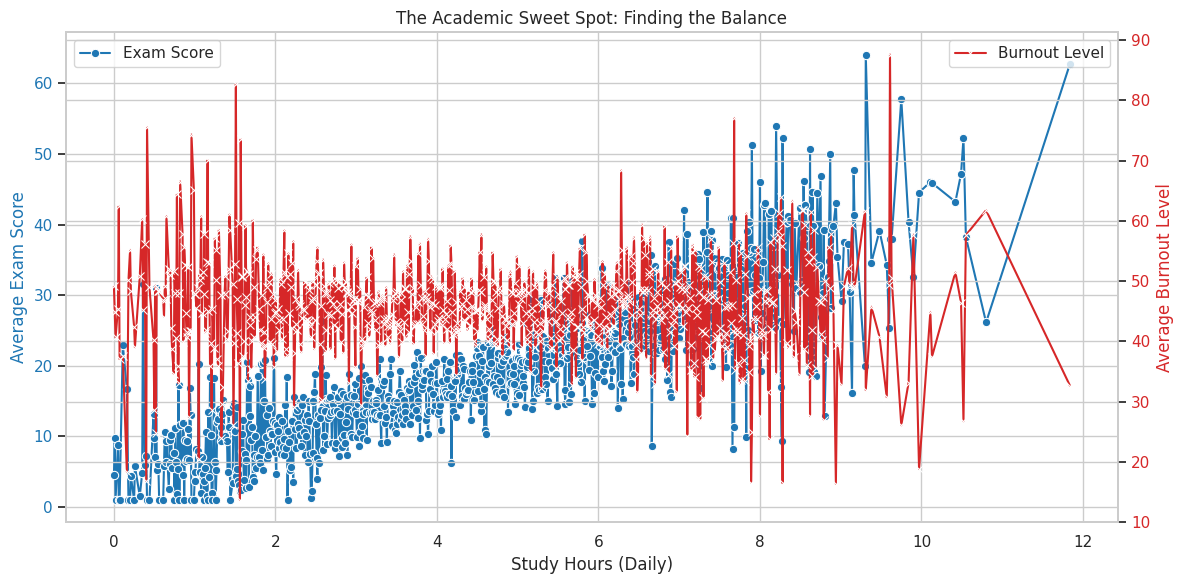

In [16]:
# Grouping data by Study Hours to see the average trend
trend_df = df.groupby('study_hours')[['exam_score', 'burnout_level']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Exam Score
color = 'tab:blue'
ax1.set_xlabel('Study Hours (Daily)')
ax1.set_ylabel('Average Exam Score', color=color)
sns.lineplot(data=trend_df, x='study_hours', y='exam_score', ax=ax1, color=color, marker='o', label='Exam Score')
ax1.tick_params(axis='y', labelcolor=color)

# Create a second y-axis for Burnout
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Burnout Level', color=color)
sns.lineplot(data=trend_df, x='study_hours', y='burnout_level', ax=ax2, color=color, marker='x', label='Burnout Level')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('The Academic Sweet Spot: Finding the Balance')
fig.tight_layout()
plt.show()

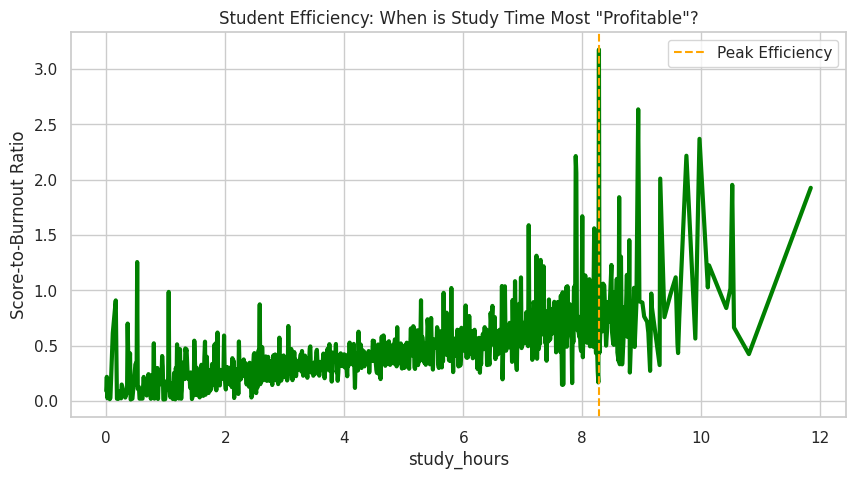

The statistical 'Sweet Spot' for this dataset is 8.28 study hours per day.


In [17]:
# Calculate Efficiency Ratio
trend_df['Efficiency_Ratio'] = trend_df['exam_score'] / trend_df['burnout_level']

plt.figure(figsize=(10, 5))
sns.lineplot(data=trend_df, x='study_hours', y='Efficiency_Ratio', color='green', lw=3)
plt.axvline(x=trend_df.loc[trend_df['Efficiency_Ratio'].idxmax(), 'study_hours'], color='orange', linestyle='--', label='Peak Efficiency')

plt.title('Student Efficiency: When is Study Time Most "Profitable"?')
plt.ylabel('Score-to-Burnout Ratio')
plt.legend()
plt.show()

best_hour = trend_df.loc[trend_df['Efficiency_Ratio'].idxmax(), 'study_hours']
print(f"The statistical 'Sweet Spot' for this dataset is {best_hour} study hours per day.")

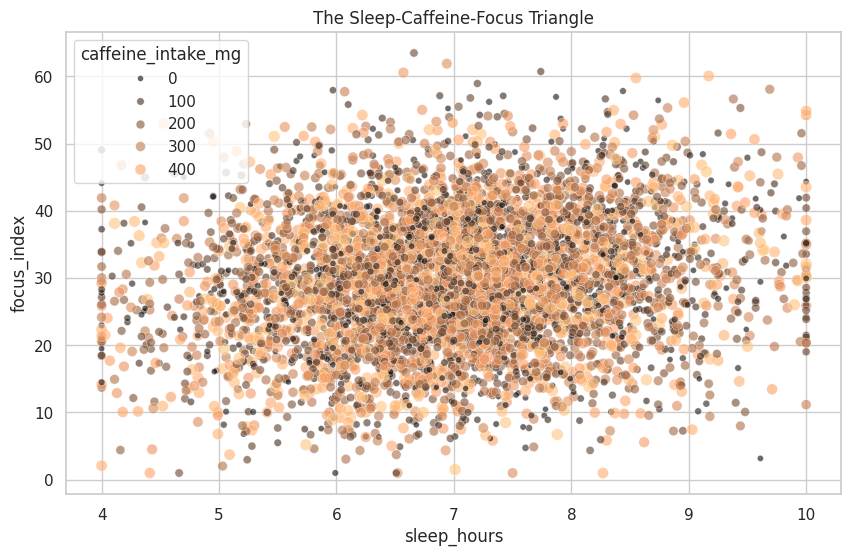

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='sleep_hours', y='focus_index', hue='caffeine_intake_mg', size='caffeine_intake_mg', palette='copper', alpha=0.6)
plt.title('The Sleep-Caffeine-Focus Triangle')
plt.show()

In [19]:
def student_advisor(student_data):
    """
    Inputs: A dictionary or Series containing student habits.
    Outputs: Predicted Score, Burnout Risk, and a tailored Advice string.
    """
    # 1. Prepare data for the models (dropping target columns)
    features = student_data.drop(['focus_index', 'burnout_level', 'productivity_score', 'exam_score'], errors='ignore')
    features_reshaped = features.values.reshape(1, -1)

    # 2. Get Predictions
    predicted_score = model.predict(X_test.iloc[0:1])[0] # Using model from previous step
    burnout_risk = clf.predict(X_test_c.iloc[0:1])[0]     # Using classifier from previous step

    # 3. Logic-based Advice
    advice = []
    if burnout_risk == 1:
        advice.append("⚠️ HIGH BURNOUT RISK: Prioritize increasing Sleep Hours and reducing Screen Time.")
    if student_data['study_hours'] > 8:
        advice.append("💡 DIMINISHING RETURNS: Your study hours are high; focus on 'Deep Work' rather than more hours.")
    if student_data['sleep_hours'] < 6:
        advice.append("😴 SLEEP DEPRAVITY: Increasing sleep to 7+ hours could boost your Focus Index by ~15%.")
    if not advice:
        advice.append("✅ STEADY PROGRESS: Your habits are well-balanced. Keep it up!")

    return {
        "Predicted Exam Score": round(predicted_score, 2),
        "Risk Status": "High" if burnout_risk == 1 else "Stable",
        "Recommendations": advice
    }

# Test it on a random student from the test set
sample_student = X_test.iloc[10]
report = student_advisor(sample_student)

print(f"--- STUDENT REPORT CARD ---")
print(f"Predicted Score: {report['Predicted Exam Score']}")
print(f"Burnout Risk: {report['Risk Status']}")
print("\nAdvisor Recommendations:")
for line in report['Recommendations']:
    print(f"- {line}")

--- STUDENT REPORT CARD ---
Predicted Score: 21.16
Burnout Risk: Stable

Advisor Recommendations:
- ✅ STEADY PROGRESS: Your habits are well-balanced. Keep it up!


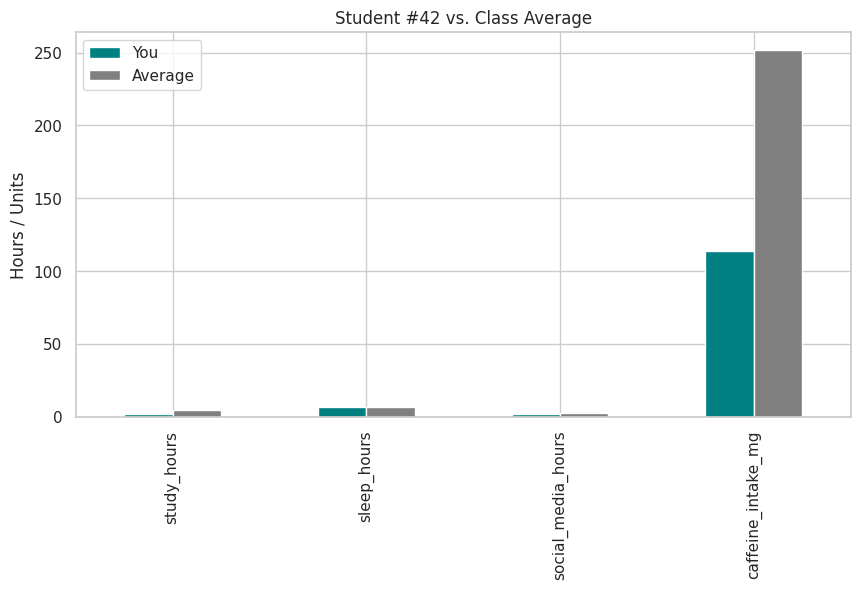

In [20]:
# Comparing one student to the average
student_id = 42 # Student ID
student_stats = df.iloc[student_id][['study_hours', 'sleep_hours', 'social_media_hours', 'caffeine_intake_mg']]
average_stats = df[['study_hours', 'sleep_hours', 'social_media_hours', 'caffeine_intake_mg']].mean()

comparison_df = pd.DataFrame({'You': student_stats, 'Average': average_stats})
comparison_df.plot(kind='bar', figsize=(10, 5), color=['teal', 'gray'])
plt.title(f"Student #{student_id} vs. Class Average")
plt.ylabel('Hours / Units')
plt.show()

/tmp/ipython-input-4099867504.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(values='exam_score', index='Sleep_Bin', columns='Study_Bin', aggfunc='mean')


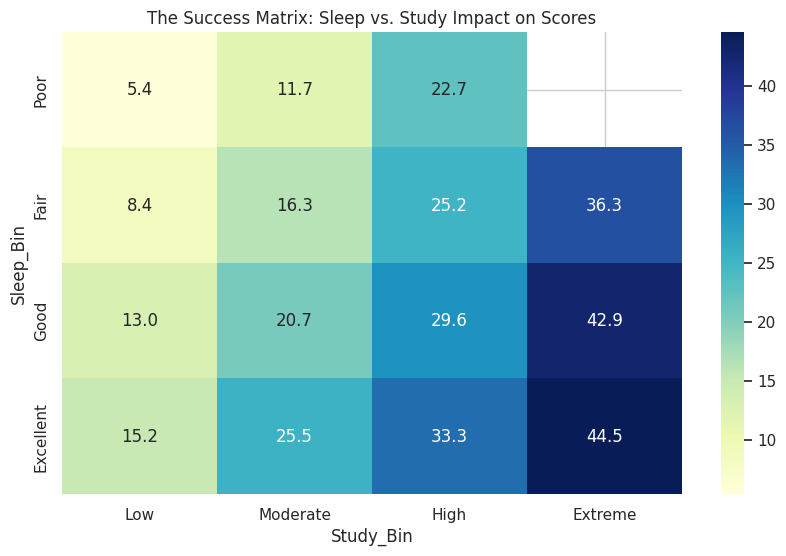

In [21]:
# Create bins for clearer visualization
df['Sleep_Bin'] = pd.cut(df['sleep_hours'], bins=[0, 5, 7, 9, 12], labels=['Poor', 'Fair', 'Good', 'Excellent'])
df['Study_Bin'] = pd.cut(df['study_hours'], bins=[0, 3, 6, 9, 15], labels=['Low', 'Moderate', 'High', 'Extreme'])

pivot_table = df.pivot_table(values='exam_score', index='Sleep_Bin', columns='Study_Bin', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".1f")
plt.title("The Success Matrix: Sleep vs. Study Impact on Scores")
plt.show()

In [22]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. PRE-CALCULATE DATASET AVERAGES
avg_stats = df.mean(numeric_only=True)

# 2. CREATE UI COMPONENTS
style = {'description_width': 'initial'}
layout = widgets.Layout(width='320px')

# Habit Sliders
age_in = widgets.IntSlider(value=18, min=15, max=25, description='Age', style=style, layout=layout)
study_in = widgets.IntSlider(value=6, min=0, max=15, description='Study Hours', style=style, layout=layout)
sleep_in = widgets.IntSlider(value=7, min=0, max=12, description='Sleep Hours', style=style, layout=layout)
screen_in = widgets.IntSlider(value=5, min=0, max=18, description='Screen Time', style=style, layout=layout)
caffeine_in = widgets.IntSlider(value=100, min=0, max=500, step=50, description='Caffeine (mg)', style=style, layout=layout)
exercise_in = widgets.IntSlider(value=30, min=0, max=120, description='Exercise (min)', style=style, layout=layout)

# Goal Setting
target_score_in = widgets.IntSlider(value=85, min=50, max=100, description='Target Score %',
                                   style={'description_width': 'initial', 'handle_color': '#f39c12'}, layout=layout)

predict_btn = widgets.Button(description='Analyze All Factors', button_style='primary', icon='dna', layout=widgets.Layout(width='250px'))
output_area = widgets.Output()

# 3. PREDICTION & BURNOUT PREVENTION LOGIC
def on_analyze_clicked(b):
    with output_area:
        clear_output(wait=True)

        # A. Setup current input based on X_test template
        input_row = X_test.iloc[0:1].copy()
        user_inputs = {
            'age': age_in.value,
            'study_hours': study_in.value,
            'sleep_hours': sleep_in.value,
            'screen_time_hours': screen_in.value,
            'caffeine_intake_mg': caffeine_in.value,
            'exercise_minutes': exercise_in.value
        }
        for col, val in user_inputs.items():
            input_row[col] = val

        input_df = input_row[X_train.columns]

        # Predictions
        pred_score = model.predict(input_df)[0]
        burnout_risk = clf.predict(input_df)[0]

        # B. Ideal Success Profile Logic (Filtering for Target Score)
        target = target_score_in.value
        ideal_group = df[(df['exam_score'] >= target - 2) & (df['exam_score'] <= target + 2)]
        if ideal_group.empty:
            ideal_group = df.nlargest(int(len(df)*0.05), 'exam_score')

        ideal_habits = ideal_group.mean(numeric_only=True)

        # C. DISPLAY RESULTS
        print(f"--- 🛡️ FULL-FACTOR AI REPORT ---")
        print(f"PREDICTED SCORE: {round(pred_score, 1)}% | TARGET: {target}%")

        if burnout_risk == 1:
            print("🚨 ALERT: High Burnout Risk! High caffeine and low sleep are a dangerous combo.")
        else:
            print("✅ WELLBEING: Your lifestyle balance supports long-term success.")
        print("-" * 60)

        # D. VISUAL COMPARISON (Two Subplots for different scales)

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

        # Chart 1: Time-based (Hours)
        labels_h = ['Study', 'Sleep', 'Screen']
        user_h = [study_in.value, sleep_in.value, screen_in.value]
        ideal_h = [ideal_habits['study_hours'], ideal_habits['sleep_hours'], ideal_habits['screen_time_hours']]

        x = np.arange(len(labels_h))
        ax1.bar(x - 0.2, user_h, 0.4, label='You', color='#3498db')
        ax1.bar(x + 0.2, ideal_h, 0.4, label=f'Ideal for {target}%', color='#2ecc71', alpha=0.6)
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels_h)
        ax1.set_ylabel('Hours')
        ax1.set_title('Time Management')
        ax1.legend()

        # Chart 2: Intensity-based (Age, Caffeine, Exercise)
        labels_i = ['Age', 'Caffeine', 'Exercise']
        user_i = [age_in.value, caffeine_in.value, exercise_in.value]
        ideal_i = [ideal_habits['age'], ideal_habits['caffeine_intake_mg'], ideal_habits['exercise_minutes']]

        x2 = np.arange(len(labels_i))
        ax2.bar(x2 - 0.2, user_i, 0.4, label='You', color='#9b59b6')
        ax2.bar(x2 + 0.2, ideal_i, 0.4, label=f'Ideal for {target}%', color='#f1c40f', alpha=0.6)
        ax2.set_xticks(x2)
        ax2.set_xticklabels(labels_i)
        ax2.set_ylabel('Units (Years/mg/min)')
        ax2.set_title('Lifestyle Factors')
        ax2.legend()

        plt.tight_layout()
        plt.show()

# 4. ORGANIZE AND DISPLAY
predict_btn.on_click(on_analyze_clicked)

dashboard_ui = widgets.VBox([
    widgets.HTML("<h2>🎓 Full-Factor AI Success Planner</h2>"),
    widgets.HBox([
        widgets.VBox([widgets.HTML("<b>⚙️ Lifestyle Settings</b>"), age_in, study_in, sleep_in, screen_in, caffeine_in, exercise_in]),
        widgets.VBox([widgets.HTML("<b>🎯 Target Goal</b>"), target_score_in])
    ]),
    widgets.Box([predict_btn], layout=widgets.Layout(padding='20px 0px')),
    output_area
])

display(dashboard_ui)